In [1]:
import tensorflow as tf;    print("tensorflow   ", tf.__version__)
import numpy as np;         print("numpy        ", np.__version__)
import PIL;                 print("Pillow (PIL) ", PIL.__version__)
import streamlit;           print("streamlit    ", streamlit.__version__)
import matplotlib;          print("matplotlib   ", matplotlib.__version__)
import seaborn as sns;      print("seaborn      ", sns.__version__)
import sklearn;             print("scikit-learn ", sklearn.__version__)

tensorflow    2.16.1
numpy         1.26.4
Pillow (PIL)  11.1.0
streamlit     1.51.0
matplotlib    3.10.7
seaborn       0.13.2
scikit-learn  1.7.2


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

from sklearn.metrics import confusion_matrix 

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Activation

from tensorflow.keras.utils import load_img
from tensorflow.keras.preprocessing import image
from tensorflow.keras.layers import RandomRotation
from tensorflow.keras.layers import RandomContrast
from tensorflow.keras.layers import RandomZoom
from tensorflow.keras.layers import RandomFlip
from tensorflow.keras.layers import RandomTranslation
from tensorflow.keras.layers import BatchNormalization

from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import ModelCheckpoint

print(f'Tensorflow Version: {tf.__version__}')

SEED = 111

%config InLineBackend.figure_format = 'retina'
plt.rcParams["figure.figsize"] = (16, 10)
plt.rcParams.update({'font.size' : 14})

2026-01-30 13:18:48.272980: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-30 13:18:48.879930: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Tensorflow Version: 2.16.1


In [3]:
def get_data_labels(directory, shuffle = True, random_state = 0):
    from sklearn.utils import shuffle
    data_path = []
    data_index = []
    class_names = sorted(os.listdir(directory))
    label_dict = {class_name: idx for idx, class_name in enumerate(class_names)}
    # label_dict = {label: index for label, index in enumerate(sorted(os.listdir(directory)))}

    for label, index in label_dict.items():
        label_dir = os.path.join(directory, label)
        for image in os.listdir(label_dir):
            image_path = os.path.join(label_dir, image)
            data_path.append(image_path)
            data_index.append(index)

    if shuffle:
        data_path, data_index = shuffle(data_path, data_index, random_state = random_state)

    return data_path, data_index

def parse_function(filename, label, image_size, n_channels):
    image_string = tf.io.read_file(filename)
    image = tf.image.decode_jpeg(image_string, n_channels)
    image = tf.image.resize(image, image_size)
    return image, label


def get_dataset(paths, labels, image_size, n_channels=1, num_classes = 4, batch_size = 32):
    path_ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    
    image_label_ds = path_ds.map(lambda path, label: parse_function(path, label, image_size, n_channels),
                                 num_parallel_calls = tf.data.AUTOTUNE)
    return image_label_ds.batch(batch_size).prefetch(buffer_size = tf.data.AUTOTUNE)
    

In [4]:
USER_PATH = "dataset"
train_paths, train_index = get_data_labels(USER_PATH + '/Training', random_state = SEED)
test_paths, test_index = get_data_labels(USER_PATH + '/Testing', random_state = SEED)

print('Training')
print(f'Number of Paths: {len(train_paths)}')
print(f'Number of Labels: {len(train_index)}')
print('\nTesting')
print(f'Number of Paths: {len(test_paths)}')
print(f'Number of Labels: {len(test_index)}')

batch_size = 32
image_dim = (168, 168)
train_ds = get_dataset(train_paths, train_index, image_dim, n_channels = 1, num_classes = 4, batch_size = batch_size)
test_ds = get_dataset(test_paths, test_index, image_dim, n_channels = 1, num_classes = 4, batch_size = batch_size)

print(f'\nTraining Dataset: {len(train_ds)}')
print(f'\nTesting Dataset: {len(test_ds)}')

class_mappings = {'Glioma': 0, 'Meninigioma': 1, 'Notumor': 2, 'Pituitary': 3}
inv_class_mapping = {v: k for k, v in class_mappings.items()}
class_names = list(class_mappings.keys())

Training
Number of Paths: 5712
Number of Labels: 5712

Testing
Number of Paths: 1311
Number of Labels: 1311

Training Dataset: 179

Testing Dataset: 41


2026-01-30 13:18:49.463970: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-01-30 13:18:49.493152: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-01-30 13:18:49.495888: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

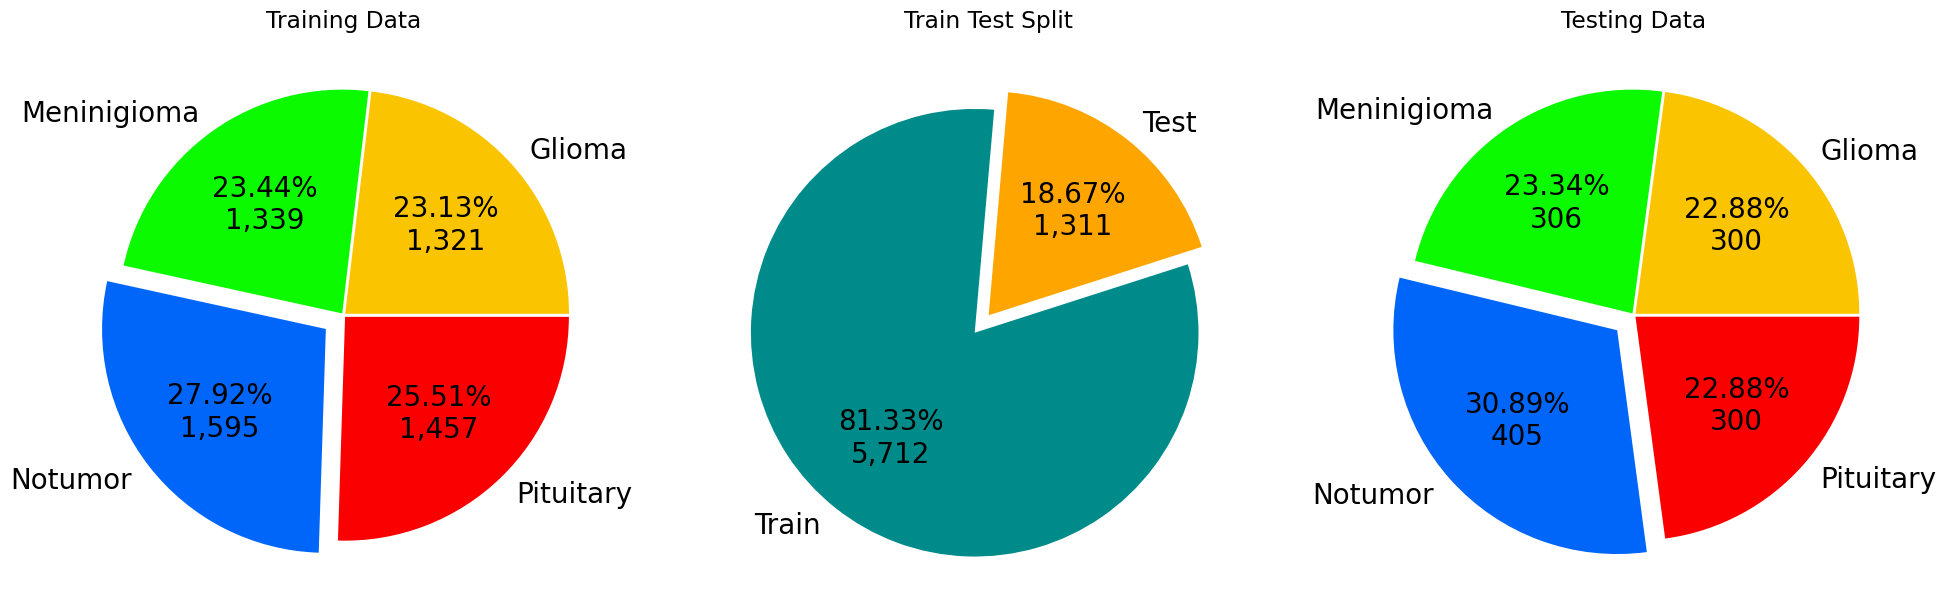

In [5]:
fig, ax = plt.subplots(ncols=3, figsize=(20, 14))

# ---------- Training Data ----------
train_class_counts = [
    train_index.count(class_mappings[class_name])
    for class_name in class_names
]

ax[0].set_title('Training Data')
ax[0].pie(
    train_class_counts,
    labels=class_names,
    colors=['#FAC500', '#0BFA00', '#0066FA', '#FA0000'],
    autopct=lambda p: '{:.2f}%\n{:,.0f}'.format(
        p, p * sum(train_class_counts) / 100
    ),
    explode=(0.01, 0.01, 0.1, 0.01),
    textprops={'fontsize': 20}
)

# ---------- Train / Test Split ----------
total_samples = len(train_index) + len(test_index)

ax[1].set_title('Train Test Split')
ax[1].pie(
    [len(train_index), len(test_index)],
    labels=['Train', 'Test'],
    colors=['darkcyan', 'orange'],
    autopct=lambda p: '{:.2f}%\n{:,.0f}'.format(
        p, p * total_samples / 100
    ),
    explode=(0.1, 0),
    startangle=85,
    textprops={'fontsize': 20}
)

# ---------- Testing Data ----------
test_class_counts = [
    test_index.count(class_mappings[class_name])
    for class_name in class_names
]

ax[2].set_title('Testing Data')
ax[2].pie(
    test_class_counts,
    labels=class_names,
    colors=['#FAC500', '#0BFA00', '#0066FA', '#FA0000'],
    autopct=lambda p: '{:.2f}%\n{:,.0f}'.format(
        p, p * sum(test_class_counts) / 100
    ),
    explode=(0.01, 0.01, 0.1, 0.01),
    textprops={'fontsize': 20}
)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=300, bbox_inches='tight')
plt.show()


In [6]:
def show_images(paths, labels, class_mappings,
                index_list=range(10), im_size=250, figsize=(12, 8)):

    num_images = len(index_list)
    num_rows = (num_images + 3) // 4

    index_to_class = {v: k for k, v in class_mappings.items()}

    fig, ax = plt.subplots(nrows=num_rows, ncols=4, figsize=figsize)
    ax = ax.flatten()

    for i, index in enumerate(index_list):
        if i >= len(ax) or index >= len(paths):
            break

        image = load_img(
            paths[index],
            target_size=(im_size, im_size),
            color_mode='grayscale'
        )

        ax[i].imshow(image, cmap='gray')
        class_name = index_to_class[labels[index]]
        ax[i].set_title(f'Index {index} : {class_name}')
        ax[i].axis('off')

    
    for j in range(i + 1, len(ax)):
        ax[j].axis('off')

    plt.tight_layout()
    plt.show()


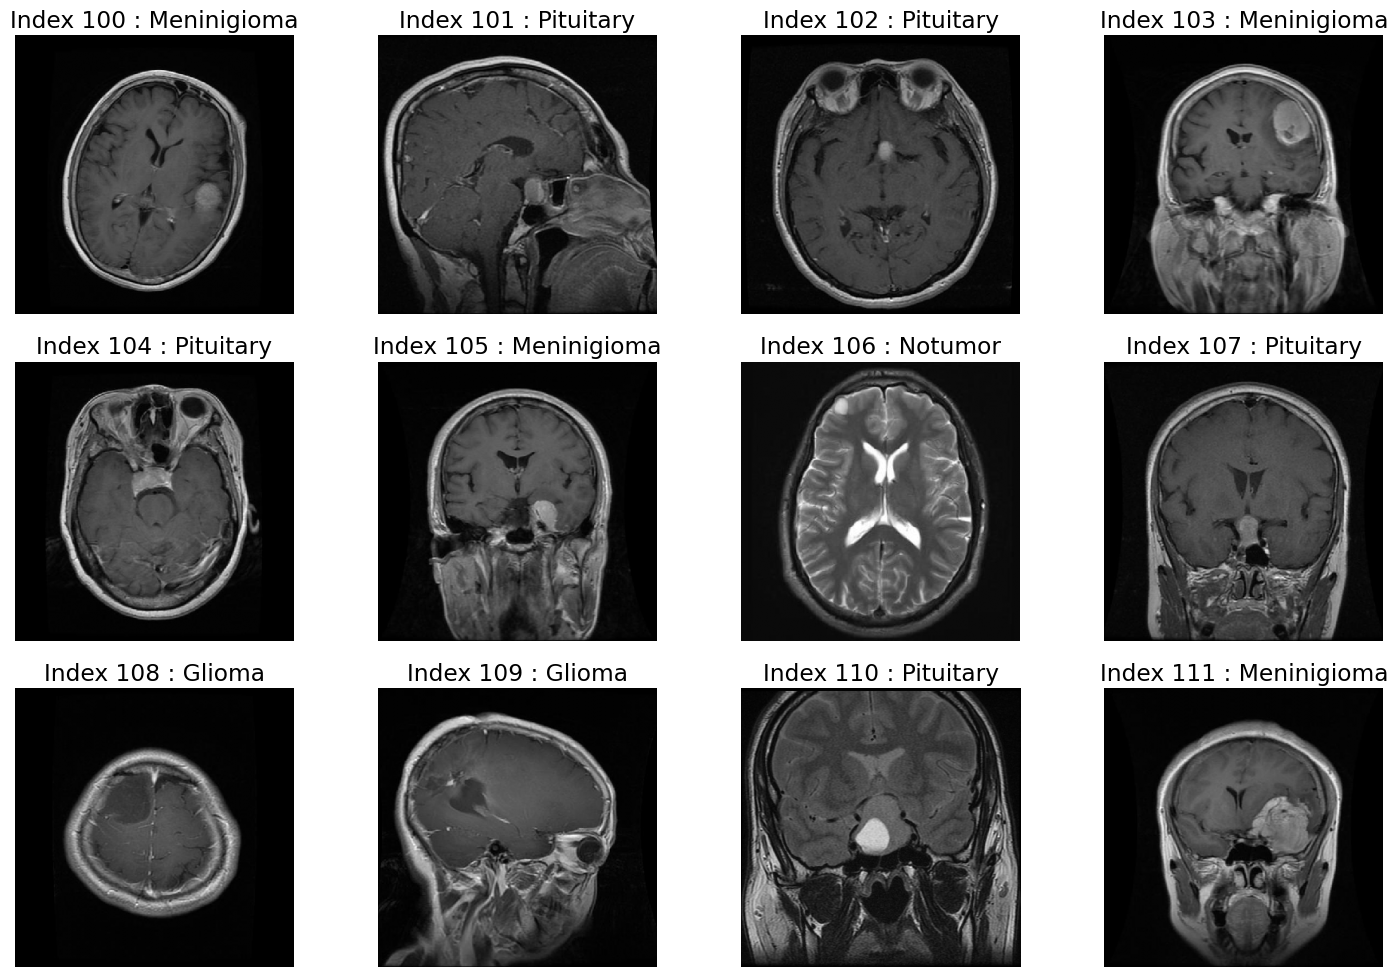

In [7]:
show_images(train_paths, train_index, class_mappings, im_size = 350, figsize = (15,10), index_list = range(100, 112))

In [8]:
data_augmentation = Sequential([
    RandomFlip('horizontal'),
    RandomRotation(0.02, fill_mode = 'constant'),
    RandomContrast(0.1),
    RandomZoom(height_factor = 0.01, width_factor = 0.05),
    RandomTranslation(height_factor = 0.0015, width_factor = 0.0015, fill_mode = 'constant')
])

def preprocess_train(image, label):
    image = tf.cast(image, tf.float32)
    image = data_augmentation(image) / 255.0
    return image, label

def preprocess_test(image, label):
    return image / 255.0, label


train_ds_preprocessed = train_ds.map(preprocess_train, num_parallel_calls = tf.data.AUTOTUNE)
test_ds_preprocessed = test_ds.map(preprocess_test, num_parallel_calls = tf.data.AUTOTUNE)

In [9]:
# def plot_augmented_images(dataset, shape, class_mappings, figsize=(15, 6)):
#     plt.figure(figsize = figsize)
#     index_to_class = {v: k for k, v in class_mappings.items()}
#     for images, label in dataset.take(1):
#         i = 0
#         for i in range(shape[0] * shape[1]):
#             ax = plt.subplot(shape[0], shape[1], i+1)
#             plt.imshow(images[i].numpy().squeeze(), cmap='gray')
#             plt.title(index_to_class[label.numpy()[i]])
#             plt.axis('off')
#             i += 1
#     plt.tight_layout()
#     plt.show()

def plot_augmented_images(dataset, shape, class_mappings, figsize=(15, 6)):
    
    index_to_class = {v: k for k, v in class_mappings.items()}
    plt.figure(figsize=figsize)
    
    for images, labels in dataset.take(1):
        num_images = min(shape[0] * shape[1], images.shape[0])
    
        for i in range(num_images):
            ax = plt.subplot(shape[0], shape[1], i + 1)
    
            plt.imshow(images[i].numpy().squeeze(), cmap='gray')
            class_name = index_to_class[int(labels.numpy()[i])]
            plt.title(class_name)
            plt.axis('off')
    
    plt.tight_layout()
    plt.show()


2026-01-30 13:18:51.773561: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


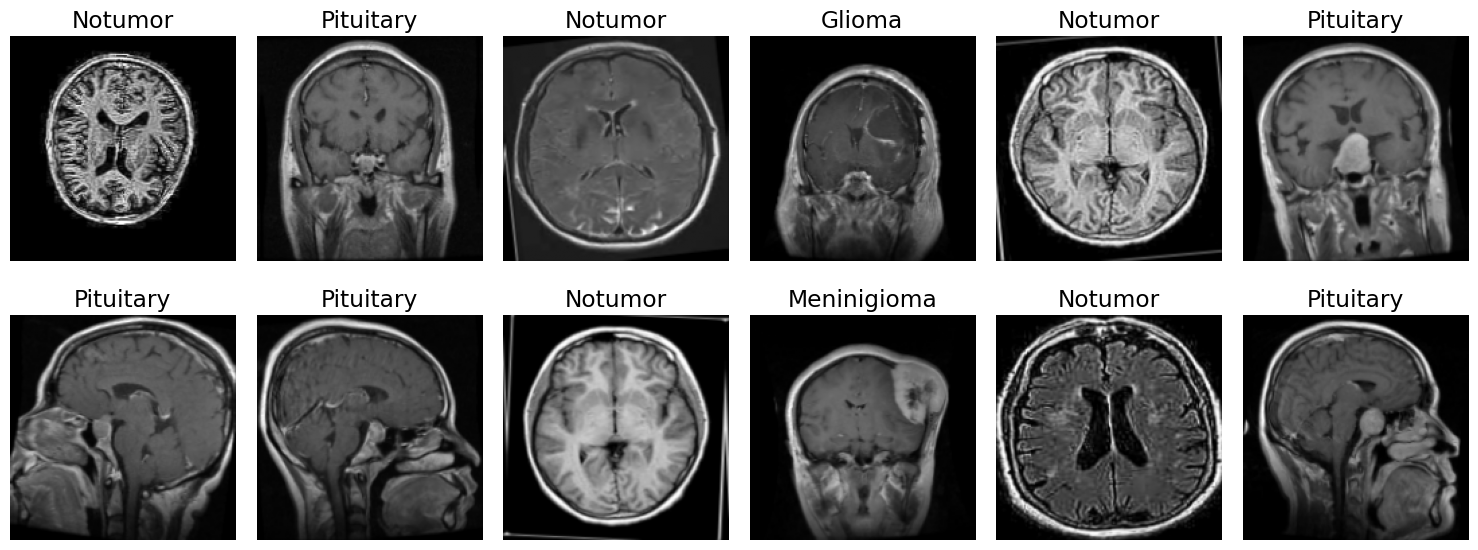

In [10]:
plot_augmented_images(train_ds_preprocessed, shape = (2, 6), class_mappings = class_mappings)

In [11]:
num_classes = len(class_mappings.keys())
image_shape = (image_dim[0], image_dim[1], 1)

epochs = 50
print(f'Number of Classes: {num_classes}')
print(f'Image shape: {image_shape}')
print(f'Epochs: {epochs}')
print(f'Batch size: {batch_size}')

def encode_labels(image, label):
    return image, tf.one_hot(label, depth = num_classes)

train_ds_preprocessed = train_ds_preprocessed.map(encode_labels, num_parallel_calls = tf.data.AUTOTUNE)
test_ds_preprocessed = test_ds_preprocessed.map(encode_labels, num_parallel_calls = tf.data.AUTOTUNE)

Number of Classes: 4
Image shape: (168, 168, 1)
Epochs: 50
Batch size: 32


In [12]:
model = Sequential([
    Input(shape = image_shape),

    Conv2D(64, (5, 5), activation = 'relu'),
    MaxPooling2D(pool_size = (3,3)),

    Conv2D(64, (5, 5), activation = 'relu'),
    MaxPooling2D(pool_size = (3,3)),

    Conv2D(128, (4, 4), activation = 'relu'),
    MaxPooling2D(pool_size = (2,2)),

    Conv2D(128, (4,4), activation = 'relu'),
    MaxPooling2D(pool_size = (2,2)),
    Flatten(),

    Dense(512, activation = 'relu'),
    Dense(num_classes, activation = 'softmax')
])


model.summary()

optimizer = Adam(learning_rate = 0.001, beta_1 = 0.85, beta_2 = 0.9925)

model.compile(optimizer = optimizer, loss = 'categorical_crossentropy', metrics = ['accuracy'])


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 164, 164, 64)   │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 50, 64)     │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 13, 13, 128)    │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 3, 3, 128)      │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 565,700 (2.16 MB)

 Trainable params: 565,700 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# class ReduceLROnMultipleAccuracies(tf.keras.callbacks.Callback):
#     def __init__(self, thresholds, factor, monitor='val_accuracy', verbose=1):
#         super(ReduceLROnMultipleAccuracies.self).__init__()
#         self.thresholds = thresholds
#         self.factor = factor
#         self.monitor = monitor
#         self.verbose = verbose
#         self.thresholds_reached = [False] * len(thresholds)

#     def on_epoch_end(self, epoch, logs=None):
#         current_accuracy = logs.get(self.monitor)
#         for i, threshold in enumerate(self.thresholds):
#             if current_accuracy >= threshold and not self.thresholds_reached[i]:
#                 optimizer = self.model.optimizer
#                 old_lr = optimizer.learning_rate.numpy()
#                 new_lr = old_lr * self.factor
#                 optimizer.learning_rate.assign(new_lr)
#                 self.thresholds_reached[i] = True
#                 if self.verbose > 0:
#                     print(f'\nepoch {epoch+1}: {self.monitor} reached {threshold}. Reducing learning rate from {old_lr} to {new_lr}.')



class ReduceLROnMultipleAccuracies(tf.keras.callbacks.Callback):
    def __init__(self, thresholds, factor=0.75, monitor='val_accuracy', verbose=1):
        super().__init__()
        self.thresholds = thresholds
        self.factor = factor
        self.monitor = monitor
        self.verbose = verbose
        self.thresholds_reached = [False] * len(thresholds)

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        current_value = logs.get(self.monitor)

        if current_value is None:
            return

        for i, threshold in enumerate(self.thresholds):
            if current_value >= threshold and not self.thresholds_reached[i]:
                optimizer = self.model.optimizer
                old_lr = float(tf.keras.backend.get_value(optimizer.learning_rate))
                new_lr = old_lr * self.factor
                tf.keras.backend.set_value(optimizer.learning_rate, new_lr)

                self.thresholds_reached[i] = True

                if self.verbose:
                    print(
                        f"\nEpoch {epoch+1}: "
                        f"{self.monitor} reached {threshold:.4f}. "
                        f"LR reduced from {old_lr:.6f} → {new_lr:.6f}"
                    )

thresholds = [0.90, 0.99, 0.9935]
lr_callbacks = ReduceLROnMultipleAccuracies(thresholds=thresholds, factor=0.75, monitor='val_accuracy', verbose=False)


In [14]:
model_rlr = ReduceLROnPlateau(monitor='val_loss', factor=0.8, min_lr=1e-4, patience=4, verbose=False)
model_mc = ModelCheckpoint('best_model.keras', monitor='val_accuracy', mode='max', save_best_only=True, verbose=False)

history = model.fit(
    train_ds_preprocessed,
    validation_data = test_ds_preprocessed,
    epochs = epochs,
    callbacks = [model_rlr, model_mc],
    verbose = True
)

Epoch 1/50


I0000 00:00:1769766533.989184   12466 service.cc:145] XLA service 0x70f79c0031e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1769766533.989211   12466 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce GTX 1650, Compute Capability 7.5
2026-01-30 13:18:54.044267: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-01-30 13:18:54.256455: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8902


  7/179 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.3803 - loss: 1.3444 

I0000 00:00:1769766538.534814   12466 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


179/179 ━━━━━━━━━━━━━━━━━━━━ 17s 62ms/step - accuracy: 0.6234 - loss: 0.8799 - val_accuracy: 0.7117 - val_loss: 0.6964 - learning_rate: 0.0010
Epoch 2/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.8270 - loss: 0.4508 - val_accuracy: 0.7994 - val_loss: 0.4953 - learning_rate: 0.0010
Epoch 3/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.8762 - loss: 0.3255 - val_accuracy: 0.8719 - val_loss: 0.3393 - learning_rate: 0.0010
Epoch 4/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.9077 - loss: 0.2509 - val_accuracy: 0.9092 - val_loss: 0.2380 - learning_rate: 0.0010
Epoch 5/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.9282 - loss: 0.1979 - val_accuracy: 0.9199 - val_loss: 0.1913 - learning_rate: 0.0010
Epoch 6/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.9415 - loss: 0.1618 - val_accuracy: 0.9588 - val_loss: 0.1389 - learning_rate: 0.0010
Epoch 7/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.9491 - loss: 0.1404 - val

In [15]:
model = load_model('best_model.keras')
test_loss, test_acc = model.evaluate(test_ds_preprocessed)
print(f'Test Accuracy: {test_acc * 100: 0.4f}%')

41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9924 - loss: 0.0638      
Test Accuracy:  99.2372%


In [16]:
np.save('history.npy', history.history)

In [17]:
history_dict = np.load('history.npy', allow_pickle=True).item()

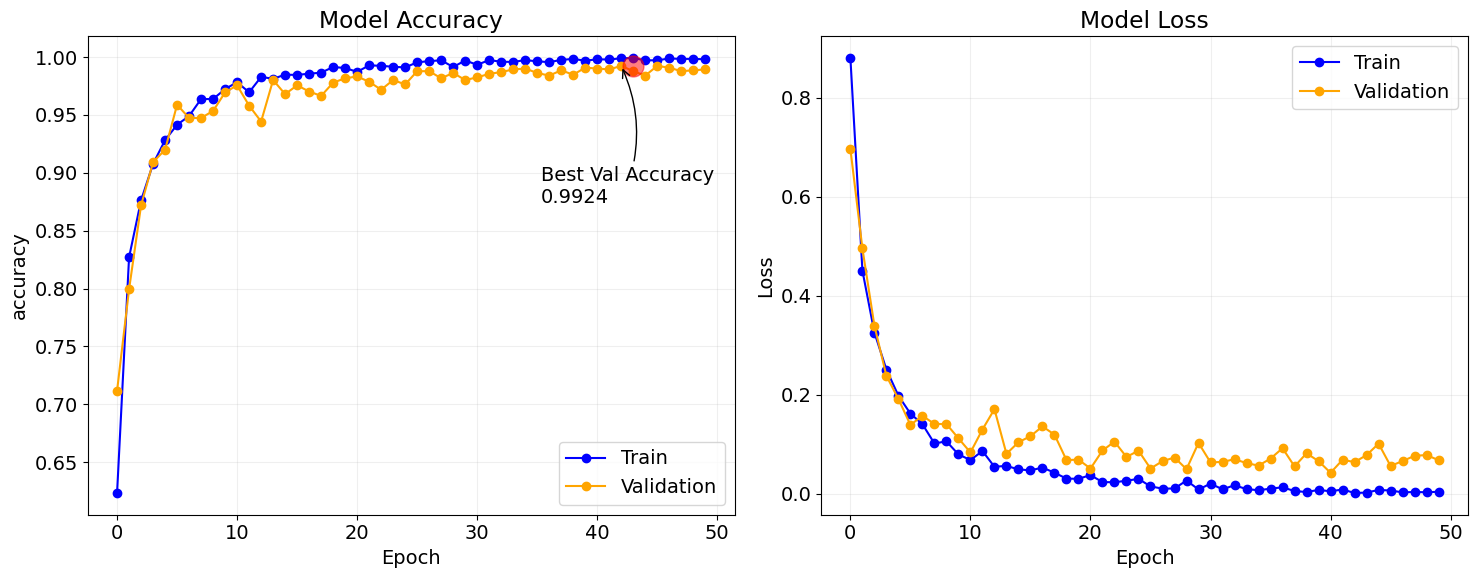

In [18]:
_, ax = plt.subplots(ncols=2, figsize=(15, 6))

ax[0].plot(history.history['accuracy'], marker='o', linestyle='-', color='blue')
ax[0].plot(history.history['val_accuracy'], marker='o', linestyle='-', color='orange')
ax[0].set_title('Model Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('accuracy')
ax[0].legend(['Train', 'Validation'], loc='lower right')
ax[0].grid(alpha=0.2)

ax[1].plot(history.history['loss'], marker='o', linestyle='-', color='blue')
ax[1].plot(history.history['val_loss'], marker='o', linestyle='-', color='orange')
ax[1].set_title('Model Loss')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
ax[1].legend(['Train', 'Validation'], loc='upper right')
ax[1].grid(alpha=0.2)

best_val_acc_epoch = np.argmax(history.history['val_accuracy']) 
best_val_acc = np.max(history.history['val_accuracy'])
ax[0].plot(best_val_acc_epoch + 1, best_val_acc, 'ro', markersize=15, alpha=0.5)
ax[0].annotate(f'Best Val Accuracy\n{best_val_acc:.4f}', xy = (best_val_acc_epoch, best_val_acc),
               xytext = (best_val_acc_epoch - 100, best_val_acc - 100), textcoords = 'offset points',
               arrowprops = dict(arrowstyle = '->', connectionstyle = 'arc3, rad=.2'))
plt.tight_layout()
plt.savefig('history.png', dpi=300, bbox_inches='tight')
plt.show()

In [26]:
# true_labels = []
# predicted_labels = []

# for images, labels in test_ds_preprocessed.unbatch():
#      true_label = np.argmax(labels.numpy())
#      true_labels.append(true_label)

#      pred = model.predict(tf.expand_dims(images, 0), verbose=False)
#      predicted_label = np.argmax(pred)
#      predicted_labels.append(predicted_label)

true_labels = []
predicted_labels = []

for images, labels in test_ds_preprocessed:
    preds = model.predict(images, verbose=False)

    true_labels.extend(np.argmax(labels.numpy(), axis=1))
    predicted_labels.extend(np.argmax(preds, axis=1))


2026-01-30 14:19:11.841313: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [32]:
def plot_confusion_matrix(true_labels, predicted_labels, class_mappings, metrics=False, cmap='Blues'):
    # Compute confusion matrix
    cm = confusion_matrix(true_labels, predicted_labels)
    plt.figure(figsize=(8,8))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=False)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

    #mapping of indices to class names in class_mappings
    plt.xticks(ticks=np.arange(num_classes) + 0.5, labels=class_mappings.keys(), ha='center')
    plt.yticks(ticks=np.arange(num_classes) + 0.5, labels=class_mappings.keys(), ha='center')
    plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()

    if metrics:
        # Precision, Recall and F1-Score for each class and Overall Accuracy
        precision = np.diag(cm) / np.sum(cm, axis=0)
        recall = np.diag(cm) / np.sum(cm, axis=1)
        f1_score = 2 * precision * recall / (precision + recall)
        accuracy = np.sum(np.diag(cm)) / np.sum(cm)

        print('Class-wise metrics:')
        for i in range(len(class_mappings)):
            class_name = list(class_mappings.keys())[i]
            print(f'\033[94mclass: {class_name}\033[0m')
            print(f'Precision: {precision[i]:.4f}')
            print(f'Recall: {recall[i]:.4f}')
            print(f'F1-Score: {f1_score[i]:.4f}\n')

        print(f'\033[92mOverall Accuracy: {accuracy:.4f}\033[0m')

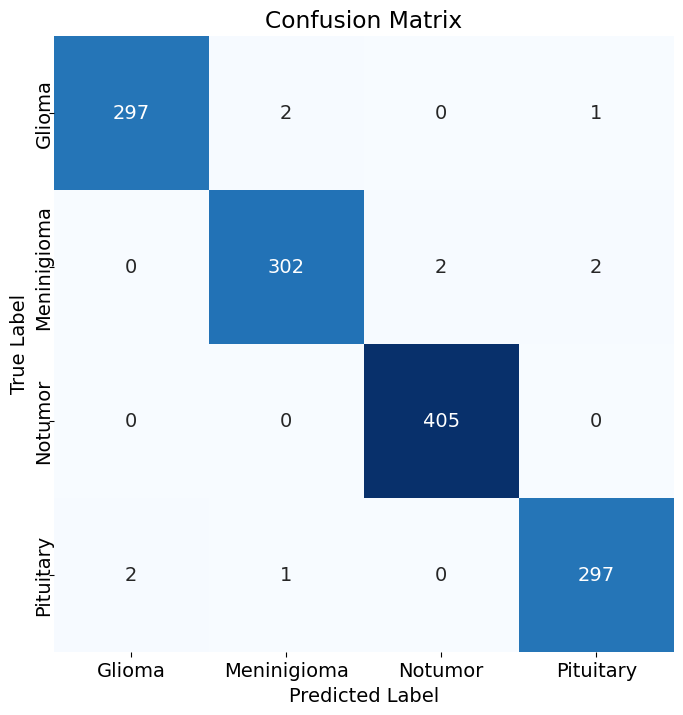

Class-wise metrics:
class: Glioma
Precision: 0.9933
Recall: 0.9900
F1-Score: 0.9917

class: Meninigioma
Precision: 0.9902
Recall: 0.9869
F1-Score: 0.9885

class: Notumor
Precision: 0.9951
Recall: 1.0000
F1-Score: 0.9975

class: Pituitary
Precision: 0.9900
Recall: 0.9900
F1-Score: 0.9900

Overall Accuracy: 0.9924


In [34]:
plot_confusion_matrix(true_labels, predicted_labels, class_mappings, metrics=True)

In [47]:
def plot_smaple_predictions(model, dataset, index_to_class, num_samples=9, figsize=(13, 12)):
    plt.figure(figsize=figsize)
    num_rows = num_cols = int(np.sqrt(num_samples))

    iterator = iter(dataset.unbatch())

    for i in range(1, num_samples + 1):
        image, true_label = next(iterator)
        image_batch = tf.expand_dims(image, 0)
        predictions = model.predict(image_batch, verbose=False)
        predicted_label = np.argmax(predictions, axis=1)[0]

        true_class_index = np.argmax(true_label.numpy())
        true_class = index_to_class[true_class_index]
        predicted_class = index_to_class[predicted_label]


        # Determine title color basec on prediction accuracy
        title_color = 'green' if true_class_index == predicted_label else 'red'

        plt.subplot(num_rows, num_cols, i)
        plt.imshow(image.numpy().squeeze(), cmap='gray')
        plt.title(f'True: {true_class}\nPred: {predicted_class}', color=title_color)
        plt.axis('off')

    plt.tight_layout()
    plt.savefig('sample_predictions.png', dpi=300, bbox_inches='tight')
    plt.show()

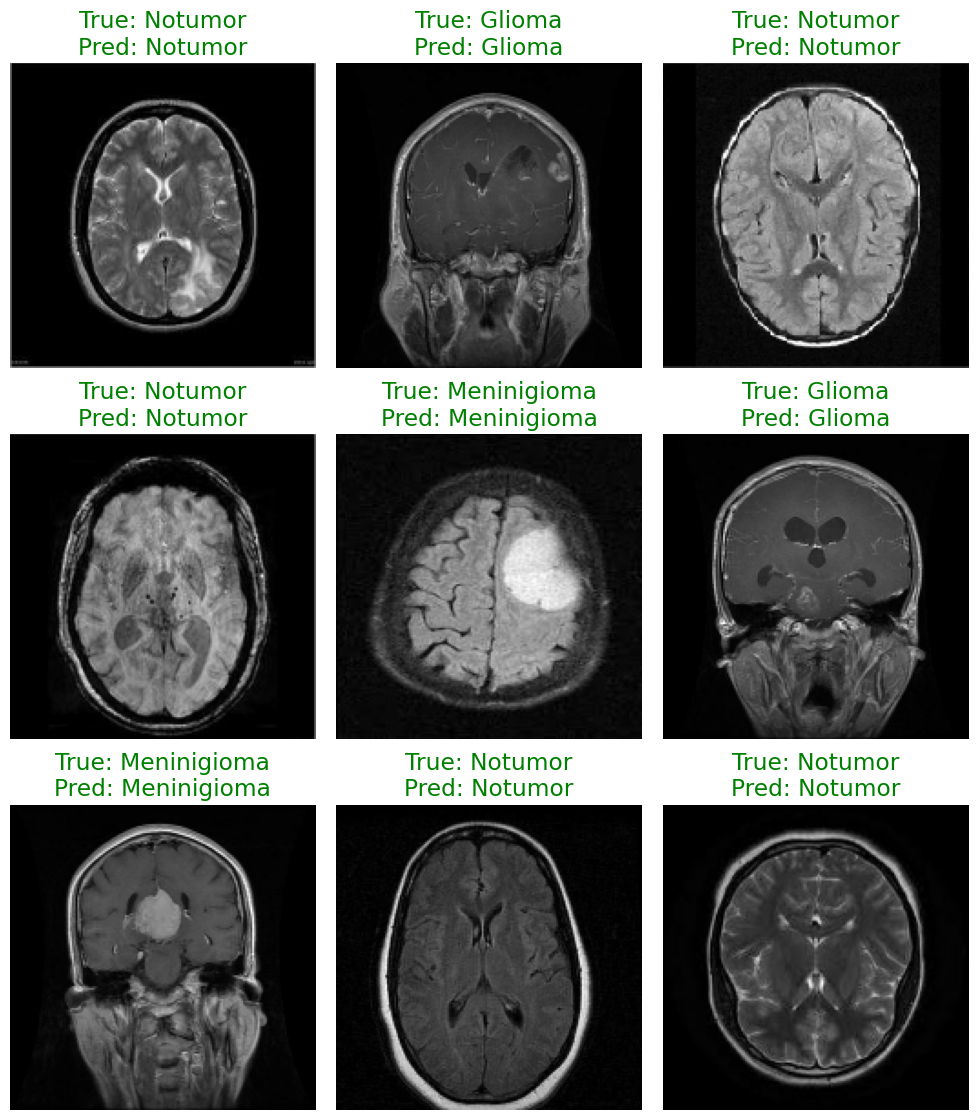

In [49]:
plot_smaple_predictions(model=model,
                       dataset=test_ds_preprocessed,
                       index_to_class=inv_class_mapping,
                       num_samples=9,
                       figsize=(10, 11.5))

In [64]:
def plot_misclassified_samples(model, dataset, index_to_class, figsize=(10,10)):
    misclassified_images = []
    misclassified_labels = []
    misclassified_predictions = []

    for image, true_label in dataset.unbatch():
        image_batch = tf.expand_dims(image, 0)
        predictions = model.predict(image_batch, verbose=False)
        predicted_label = np.argmax(predictions, axis=1)[0]
        true_class_index = np.argmax(true_label.numpy())

        if true_class_index != predicted_label:
            misclassified_images.append(image.numpy().squeeze())
            misclassified_labels.append(index_to_class[true_class_index])
            misclassified_predictions.append(index_to_class[predicted_label])

    num_misclassified = len(misclassified_images)
    cols = int(np.sqrt(num_misclassified)) + 1
    rows = num_misclassified // cols + (num_misclassified % cols > 0)

    miss_classified_zip = zip(misclassified_images, misclassified_labels, misclassified_predictions)
    plt.figure(figsize=figsize)
    for i, (image, true_label, predicted_label) in enumerate(miss_classified_zip):
        plt.subplot(rows, cols, i+1)
        plt.imshow(image, cmap='gray')
        plt.title(f'True: {true_label}\nPred: {predicted_label}', color='red')
        plt.axis('off')

    plt.tight_layout()
    plt.savefig('misclassified_samples.png', dpi=300, bbox_inches='tight')
    plt.show()

2026-01-30 14:59:20.320083: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


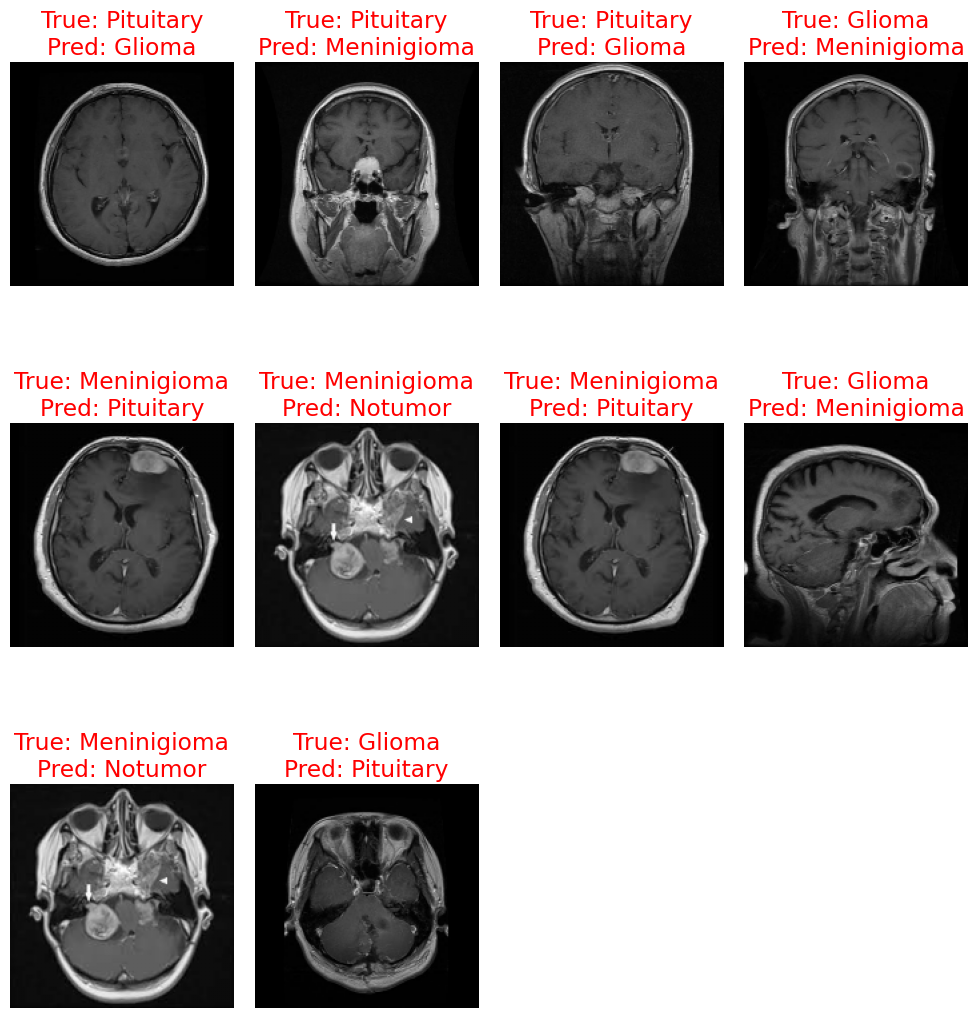

In [66]:
plot_misclassified_samples(model=model,
                       dataset=test_ds_preprocessed,
                       index_to_class=inv_class_mapping,
                       figsize=(10, 11.5))